In [ ]:
IS_ONLINE_JUDGE = False
DEBUG = True
DEBUG_QUERY = 400
DEBUG_L = 100

if IS_ONLINE_JUDGE:
    DEBUG = False

# =================================
import time

GLOBAL_START_TIME = time.perf_counter()


def debug_print(*args, **kwargs):
    if IS_ONLINE_JUDGE:
        return
    print(*args, **kwargs)


def print_elapsed_time():
    debug_print(f"elapsed time: {(time.perf_counter() - GLOBAL_START_TIME) * 1000:.2f}msecs")


# =================================
import heapq
import math
import random
from collections import defaultdict

random.seed(0)

INF = 10**18
FILE_NUM = 100


# =================================
def calc_rectangle_area(rectangle):
    l, r, t, b = rectangle
    area = (r - l) * (b - t)
    return area


def get_four_points_from_rectangle(rectangle):
    l, r, t, b = rectangle
    points = [
        (l, t),  # top left
        (r, t),  # top right
        (r, b),  # bottom right
        (l, b),  # bottom left
    ]
    return points


def calc_rectangle_dist(rectangle1, rectangle2):
    ps1 = get_four_points_from_rectangle(rectangle1)
    ps2 = get_four_points_from_rectangle(rectangle2)

    dists = []
    for p1 in ps1:
        for p2 in ps2:
            dist = calc_dist(p1, p2)
            dists.append(dist)
    return max(dists)


def calc_dist(p1: tuple, p2: tuple) -> float:
    return math.dist(p1, p2)


def prim(
    graph: dict[int, list[tuple[int, int]]],
) -> tuple[list[tuple[int, int]], list[int]]:
    """
    G: 隣接グラフ
    G := [ [(v_0, cost_0), (v_1,cost_1),..], [(v_2, cost_2)],...]

    返り値 ans :最小全域木の重みの総和
    """
    v_list = list(graph.keys())
    used = {v: False for v in v_list}

    init_v = min(v_list)  # 初期点はindex最小とする
    used[init_v] = True
    que = [(cost, init_v, v) for v, cost in graph[init_v]]
    heapq.heapify(que)

    ans_v: list[int] = [init_v]
    ans_edges: list[tuple[int, int]] = []
    while que:
        cost_v, from_v, to_v = heapq.heappop(que)
        if used[to_v]:
            continue
        used[to_v] = True
        ans_edges.append((min(from_v, to_v), max(from_v, to_v)))
        ans_v.append(to_v)
        for nxt, cost_nxt in graph[to_v]:
            if used[nxt]:
                continue
            heapq.heappush(que, (cost_nxt, to_v, nxt))
    return ans_edges, ans_v


def prim_k(graph: list[list[float]], init_v: int, k: int, used_v: set[int], N):
    """
    init_vを含むk頂点の最小全域木を求める
    """
    used = used_v | {init_v}
    used.add(init_v)
    que = [(graph[init_v][v], init_v, v) for v in range(N)]
    heapq.heapify(que)

    ans_v = [init_v]
    ans_edges: list[tuple[int, int]] = []
    ans_cost = 0.0
    while que and len(ans_v) < k:
        cost_v, from_v, to_v = heapq.heappop(que)
        if to_v in used:
            continue
        used.add(to_v)
        ans_edges.append((min(from_v, to_v), max(from_v, to_v)))
        ans_v.append(to_v)
        ans_cost += cost_v
        for nxt in range(N):
            if nxt in used:
                continue
            heapq.heappush(que, (graph[to_v][nxt], to_v, nxt))
    return ans_edges, ans_v, ans_cost


# =================================


def calc_greedy_answer(env: EnvOffline):
    graph: list[list[float]] = [[0 for _ in range(env.N)] for _ in range(env.N)]
    for i in range(env.N):
        for j in range(env.N):
            if i == j:
                continue
            dist = calc_dist(env.cneter_points[i], env.cneter_points[j])
            # dist = calc_rectangle_dist(env.rectangles[i], env.rectangles[j])
            graph[i][j] = dist
            graph[j][i] = dist

    groups = [(i, g) for i, g in enumerate(env.G)]
    groups = sorted(groups, key=lambda x: x[1], reverse=True)

    ans_edges = [None for _ in range(len(groups))]
    ans_v = [None for _ in range(len(groups))]

    now_used: set = set()
    not_used: set = set(range(env.N))
    for group_n, group_size in groups:
        v = not_used.pop()
        prim_edges, prim_v, _ = prim_k(graph, v, group_size, now_used, env.N)

        ans_edges[group_n] = prim_edges
        ans_v[group_n] = prim_v
        now_used.update(prim_v)
        not_used.difference_update(prim_v)

    return ans_v, ans_edges


class MyGraph:
    def __init__(self, vs, edges, group_ind):
        self.vs = vs
        self.edges = edges
        self.group_ind = group_ind

        self.visited_cnt = {v: 0 for v in vs}
        self._construct_graph()

    def _construct_graph(self):
        graph = defaultdict(list)
        for i, e in enumerate(self.edges):
            graph[e[0]].append(e[1])
            graph[e[1]].append(e[0])
        self.graph = graph

    def update_edges(self, remove_edge, add_edges):
        self.edges = list(set(self.edges) - set(remove_edge) | set(add_edges))
        self._construct_graph()

    def choice_min_visited(self):
        min_v = min(self.visited_cnt.values())
        min_vs = [v for v, cnt in self.visited_cnt.items() if cnt == min_v]
        return random.choice(min_vs)

    def walk_bfs(self, init_v, q_num):
        visited_v = set()
        visited_edge = set()
        q = [(None, init_v)]
        while q and len(visited_v) < q_num:
            random.shuffle(q)
            pv, v = q.pop()
            if v in visited_v:
                continue
            if pv is not None:
                visited_edge.add((min(pv, v), max(pv, v)))
            visited_v.add(v)
            for nv in self.graph[v]:
                if nv not in visited_v:
                    q.append((v, nv))

        for v in visited_v:
            self.visited_cnt[v] += 1

        return visited_v, visited_edge


def update_mst(env: EnvOffline, ans_v, ans_edges):
    group_query_cnt = [0 for _ in range(env.M)]
    group_query_v_cnt = [0 for _ in range(env.M)]

    largest_groups = []
    for g in range(env.M):
        if 3 <= len(ans_v[g]):
            group_query_cnt[g] += 1
            group_query_v_cnt[g] += env.L
            if env.L < len(ans_v[g]):
                largest_groups.append(g)

    for _ri in range(env.Q - sum(group_query_cnt)):
        min_cost = 10**9
        target_group = None
        for g in largest_groups:
            cost = group_query_v_cnt[g] / len(ans_v[g])
            if cost < min_cost:
                min_cost = cost
                target_group = g
        if target_group is not None:
            group_query_v_cnt[target_group] += env.L
            group_query_cnt[target_group] += 1

    for g in range(env.M):
        now_v = ans_v[g]
        now_edges = ans_edges[g]
        if len(now_v) < 3:
            if group_query_cnt[g] > 0:
                print(g, "ERROR")
            continue
        if 3 <= len(now_v) <= env.L:
            ans_edges[g] = env.query(now_v)
            continue

        my_graph = MyGraph(now_v, now_edges, g)
        for _ in range(group_query_cnt[g]):
            rand_v = my_graph.choice_min_visited()
            visited_v, visited_edge = my_graph.walk_bfs(rand_v, env.L)
            new_edges = env.query(visited_v)
            my_graph.update_edges(visited_edge, new_edges)
        ans_edges[g] = my_graph.edges

    return ans_v, ans_edges


def solve(env: EnvOffline):
    ans_v, ans_edges = calc_greedy_answer(env)
    ans_v, ans_edges = update_mst(env, ans_v, ans_edges)
    return ans_v, ans_edges


def main():
    if IS_ONLINE_JUDGE:
        env = EnvOnline()
        ans_v, ans_edges = solve(env)
        env.answer(ans_v, ans_edges)
    else:
        costs = []
        for file_num in range(FILE_NUM):
            debug_print("=====")
            start_time = time.perf_counter()
            input_file_path = f"../in/{file_num:04d}.txt"
            output_file_path = f"../out/{file_num:04d}.txt"
            #####
            env = EnvOffline(input_file_path, output_file_path)
            ans_v, ans_edges = solve(env)
            cost = env.answer(ans_v, ans_edges)
            #####
            debug_print(f"[{file_num}/{FILE_NUM}]: {cost} {time.perf_counter() - start_time:.2f}s")
            costs.append(cost)
        avg = sum(costs) / len(costs)
        debug_print(f"avg: {avg}")
        debug_print(f"max: {max(costs)}")
        with open("../result/mst_test02_rect.txt", "w") as f:
            f.write(f"avg: {avg}\n")
            for pi, cost in enumerate(costs):
                f.write(f"{pi:0<4} {cost}\n")

### やること

- info

  - 推測点（center で初期化）

- 400 回繰り返す
  - 適当な点を L 点選択し、最小全域木を得る
  - 収束するまで繰り返す
    - 推測点をランダムに移動させる
      - 四角形内の任意の点にしてみよう
    - 現在の推測点で最小全域木を作る
    - 真の全域木に一致する辺の個数を計算する
      - L になれば終わる
      - 前回より良くなればその移動を採択する


In [101]:
def clac_cross_point(v1, v2):
    def ccw(a, b, c):
        """3点が反時計回りかどうか判定する"""
        return (c[1] - a[1]) * (b[0] - a[0]) > (b[1] - a[1]) * (c[0] - a[0])

    p1, p2, q1, q2 = v1[0], v1[1], v2[0], v2[1]

    # 線分が交差するかを判定
    if (ccw(p1, q1, q2) != ccw(p2, q1, q2)) and (ccw(p1, p2, q1) != ccw(p1, p2, q2)):
        # 交差する場合、交点を求める
        xdiff = (p1[0] - p2[0], q1[0] - q2[0])
        ydiff = (p1[1] - p2[1], q1[1] - q2[1])

        def det(a, b):
            return a[0] * b[1] - a[1] * b[0]

        div = det(xdiff, ydiff)
        if div == 0:
            return None  # 平行な場合

        d = (det(p1, p2), det(q1, q2))
        x = det(d, xdiff) / div
        y = det(d, ydiff) / div
        return (x, y)

    return None  # 交差しない場合


def calc_rect_center(rectangle):
    """四角形の中心を計算する"""
    l, r, t, b = rectangle
    center = (l + r) / 2, (t + b) / 2
    return center


def get_rect_edge(rectangle):
    """四角形の辺を取得する"""
    l, r, t, b = rectangle
    edges = [
        ((l, t), (r, t)),  # top
        ((r, t), (r, b)),  # right
        ((r, b), (l, b)),  # bottom
        ((l, b), (l, t)),  # left
    ]
    return edges


def calc_rect_half_dist(rectangle):
    """対角線の長さを計算"""
    l, r, t, b = rectangle
    dist = math.dist((l, t), (r, b))
    return dist / 2


def calc_centroid(points):
    """点の重心を計算する"""
    x_sum = sum(p[0] for p in points)
    y_sum = sum(p[1] for p in points)
    n = len(points)
    centroid = (x_sum / n, y_sum / n)
    return centroid


def isin_rectangel(point, rectangle):
    """点が四角形の中にあるかどうかを判定する"""
    l, r, t, b = rectangle
    x, y = point
    return l <= x <= r and t <= y <= b


class MyGraph:
    def __init__(self, edges, points_dict):
        self.edges = edges
        self.points_dict = points_dict
        self._construct_graph()

    def _construct_graph(self):
        graph = defaultdict(list)
        for e in self.edges:
            graph[e[0]].append(e[1])
            graph[e[1]].append(e[0])
        self.graph = graph

    def get_centroid(self, v):
        target_points = [self.points_dict[nv] for nv in self.graph[v]]
        return calc_centroid(target_points)


class EstimatePoint:
    def __init__(self, rectangle, ind):
        self.rectangle = rectangle
        self.ind = ind
        self.move_cnt = 0
        self.estimate_coordinate = calc_rect_center(rectangle)

        self._can_move_dist = calc_rect_half_dist(rectangle)

    # def random_move(self, now_dist: float):
    #     l, r, t, b = self.rectangle
    #     random_x = random.uniform(l, r)
    #     random_y = random.uniform(t, b)
    #     self.estimate_coordinate = (random_x, random_y)
    #     self.move_cnt += 1

    def random_move(self, move_dist_mul: float):
        # 現在の推測点からrandom_vector方向に、最大移動可能距離x倍率分だけ移動する。四角形の外に出ないようにする。
        random_x = random.uniform(-1, 1)
        random_y = random.uniform(-1, 1)
        random_vec = (random_x, random_y)
        move_dist = self._can_move_dist * move_dist_mul

        p1 = self.estimate_coordinate
        tmp_p2 = p1[0] + random_vec[0], p1[1] + random_vec[1]
        now_dist = calc_dist(p1, tmp_p2)
        dist = 1 / now_dist * move_dist
        p2 = p1[0] + random_vec[0] * dist, p1[1] + random_vec[1] * dist

        for edge in get_rect_edge(self.rectangle):
            cross_point = clac_cross_point((p1, p2), edge)
            if cross_point:
                self.estimate_coordinate = cross_point
                break

        if isin_rectangel(p2, self.rectangle):
            self.estimate_coordinate = p2


def calc_point_avg_distances(points1, points2):
    distances = []
    for p1, p2 in zip(points1, points2):
        dist = calc_dist(p1, p2)
        distances.append(dist)
    avg = sum(distances) / len(distances)
    return avg

In [102]:
import matplotlib
import matplotlib.pyplot as plt

In [103]:
file_num = 0
input_file_path = f"../in/{file_num:04d}.txt"
output_file_path = f"../out/{file_num:04d}.txt"
#####
env = EnvOffline(input_file_path, output_file_path)

In [104]:
import copy


def exponential_schedule(init: float, obj: float, elapsed_time: float, max_time: float) -> float:
    """
    時間に基いて指数関数的に上昇するスケジュール
    """
    lambda_param = math.log(obj / init) / max_time
    return init * math.exp(lambda_param * elapsed_time)


def linear_schedule(init: float, obj: float, elapsed_time: float, max_time: float) -> float:
    """
    時間に基づく線形減衰・増加
    """
    return init + (obj - init) * (elapsed_time / max_time)


def calc_score(correct_vs_list, correct_edges_list, estimate_points: list[EstimatePoint]):
    correct_edge_num = 0
    all_edge_num = 0
    for now_correct_vs, now_correct_edge in zip(correct_vs_list, correct_edges_list):
        now_graph: dict[int, list] = {v: [] for v in now_correct_vs}
        for c1 in now_correct_vs:
            for c2 in now_correct_vs:
                if c1 == c2:
                    continue
                p1 = estimate_points[c1].estimate_coordinate
                p2 = estimate_points[c2].estimate_coordinate
                dist = calc_dist(p1, p2)
                now_graph[c1].append((c2, dist))
                now_graph[c2].append((c1, dist))
        ans_edges, _ = prim(now_graph)

        correct_edges_set = set(now_correct_edge)
        estimate_edges_set = set(ans_edges)
        correct_edge_num += len(correct_edges_set & estimate_edges_set)
        all_edge_num += len(estimate_edges_set)
    score = 1 - correct_edge_num / all_edge_num
    return score


def neighbor_function(estimate_points: list[EstimatePoint], now_dist_mul):
    """
    近傍解を生成する関数
    """
    ret_estimate_points = copy.deepcopy(estimate_points)
    for _ in range(10):
        N = len(ret_estimate_points)
        random_ind = random.randint(0, N - 1)
        ret_estimate_points[random_ind].random_move(now_dist_mul)
    return ret_estimate_points


def simulated_annealing(
    corrct_vs_list,
    correct_edges_list,
    estimate_points: list[EstimatePoint],
    initial_temp: float,
    init_dist: float,
    min_dist: float,
    min_temp: float,
    max_time: float,
    display: bool,
) -> tuple[tuple[list[int], list[int]], float]:
    esp = 0.01
    x = estimate_points
    current_cost = calc_score(corrct_vs_list, correct_edges_list, x)  # 初期解のコストを計算
    if current_cost <= esp:
        return x
    best_x = x
    best_cost = current_cost

    start_time = time.perf_counter()  # 開始時刻を記録
    iteration = 0

    while True:
        elapsed_time = time.perf_counter() - start_time
        if elapsed_time >= max_time:
            break
        temp = exponential_schedule(initial_temp, min_temp, elapsed_time, max_time)
        now_dist_mul = linear_schedule(init_dist, min_dist, elapsed_time, max_time)
        if temp < min_temp:
            break

        # 近傍解を生成
        new_x = neighbor_function(x, now_dist_mul)
        new_cost = calc_score(corrct_vs_list, correct_edges_list, new_x)
        if new_cost <= esp:
            debug_print(f"Iteration: {iteration}, Best cost: {new_cost}")
            return new_x
        delta_cost = new_cost - current_cost

        # 改善されるなら更新、悪化しても確率的に更新
        if delta_cost < 0 or random.random() < math.exp(-delta_cost / temp):
            x = new_x
            current_cost = new_cost

        # 最良解の更新
        if current_cost < best_cost:
            best_x = x
            best_cost = current_cost

        iteration += 1
        if display and iteration % 100 == 0:
            debug_print(f"Iteration: {iteration}, Best cost: {best_cost}, Current cost: {current_cost}")

    return best_x

In [105]:
estimate_points: list[EstimatePoint] = []
for i, rect in enumerate(env.rectangles):
    estimate_points.append(EstimatePoint(rect, i))

random_vs_list = []
random_edges_list = []
for _ in range(400):
    vs = list(range(env.N))
    random_vs = random.sample(vs, k=15)
    mst_edges = env.query(random_vs)
    random_vs_list.append(random_vs)
    random_edges_list.append(mst_edges)

corrects = [env.coordinates[i] for i in random_vs]
estimates = [estimate_points[i].estimate_coordinate for i in random_vs]

opt_estimate_points = simulated_annealing(
    corrct_vs_list=random_vs_list,
    correct_edges_list=random_edges_list,
    estimate_points=estimate_points,
    initial_temp=(1 / (100 * 100)),
    min_temp=(1 / (100 * 100)) * 0.001,
    init_dist=1,
    min_dist=0.001,
    max_time=3 * 60 * 60,
    display=True,
)

# for i in range(len(opt_target_estimate_points)):
#     ind = opt_target_estimate_points[i].ind
#     estimate_points[ind] = opt_target_estimate_points[i]
# corrects = [env.coordinates[i] for i in random_vs]
# estimates = [ep.estimate_coordinate for ep in opt_target_estimate_points]
# calc_point_avg_distances(env.coordinates, estimates)

Iteration: 100, Best cost: 0.14213655197261754, Current cost: 0.14213655197261754
Iteration: 200, Best cost: 0.1378130066654657, Current cost: 0.1378130066654657
Iteration: 300, Best cost: 0.13583138173302112, Current cost: 0.13583138173302112
Iteration: 400, Best cost: 0.13529093856962704, Current cost: 0.13547108629075844
Iteration: 500, Best cost: 0.13312916591605117, Current cost: 0.13312916591605117
Iteration: 600, Best cost: 0.1325887227526572, Current cost: 0.1325887227526572
Iteration: 700, Best cost: 0.12808502972437397, Current cost: 0.12808502972437397
Iteration: 800, Best cost: 0.12754458656098, Current cost: 0.12754458656098
Iteration: 900, Best cost: 0.12700414339758603, Current cost: 0.12700414339758603
Iteration: 1000, Best cost: 0.12502251846514145, Current cost: 0.12502251846514145
Iteration: 1100, Best cost: 0.1241217798594848, Current cost: 0.1241217798594848
Iteration: 1200, Best cost: 0.12177985948477754, Current cost: 0.12177985948477754
Iteration: 1300, Best cos

In [113]:
corrects = [env.coordinates[i] for i in range(env.N)]
estimates = [opt_estimate_points[i].estimate_coordinate for i in range(env.N)]
print(calc_point_avg_distances(env.coordinates, env.cneter_points))
print(calc_point_avg_distances(env.coordinates, estimates))

260.49903699978677
199.6685327284311


In [107]:
import numpy as np

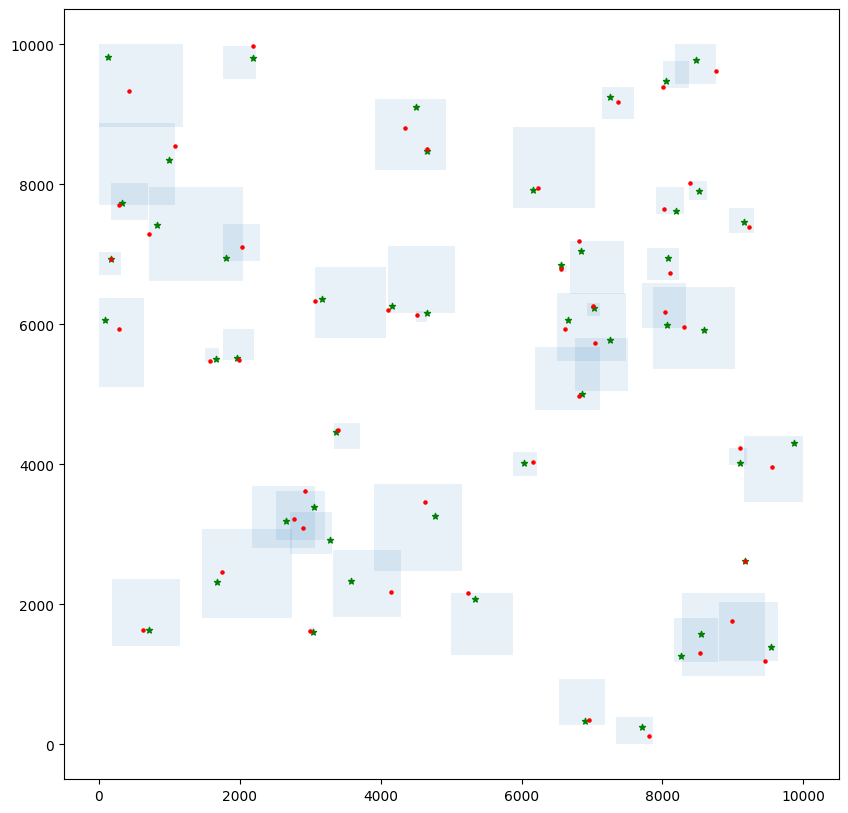

In [108]:
N = 50
corrects = np.array(corrects[:N])
estimates = np.array(estimates[:N])
rectangles = [env.rectangles[i] for i in range(N)]

# 四角形と、四角形内の正解点と予測点を描画
plt.figure(figsize=(10, 10))
ax = plt.gca()
for i, rect in enumerate(rectangles):
    l, r, t, b = rect
    ax.add_patch(matplotlib.patches.Rectangle((l, t), r - l, b - t, alpha=0.1))
ax.scatter(corrects[:, 0], corrects[:, 1], color="green", label="correct", s=20, marker="*")
ax.scatter(estimates[:, 0], estimates[:, 1], color="red", label="estimate", s=5, marker="o")
plt.show()

In [111]:
def calc_greedy_answer(env: EnvOffline, target_points):
    graph: list[list[float]] = [[0 for _ in range(env.N)] for _ in range(env.N)]
    for i in range(env.N):
        for j in range(env.N):
            if i == j:
                continue
            dist = calc_dist(target_points[i], target_points[j])
            # dist = calc_rectangle_dist(env.rectangles[i], env.rectangles[j])
            graph[i][j] = dist
            graph[j][i] = dist

    groups = [(i, g) for i, g in enumerate(env.G)]
    groups = sorted(groups, key=lambda x: x[1], reverse=True)

    ans_edges = [None for _ in range(len(groups))]
    ans_v = [None for _ in range(len(groups))]

    now_used: set = set()
    not_used: set = set(range(env.N))
    for group_n, group_size in groups:
        v = not_used.pop()
        prim_edges, prim_v, _ = prim_k(graph, v, group_size, now_used, env.N)

        ans_edges[group_n] = prim_edges
        ans_v[group_n] = prim_v
        now_used.update(prim_v)
        not_used.difference_update(prim_v)

    return ans_v, ans_edges

In [115]:
anv_v, ans_edges = calc_greedy_answer(env, estimates)
env.answer(anv_v, ans_edges)

query: 400


273426.0941338849